<a href="https://colab.research.google.com/github/lucianacrtz-blip/Trabajo-Final-Herramientas-basicas-analisis-de-Datos/blob/main/Trabajo_Final_Medicamentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




## **importar librerias y configurar opciones básicas**



In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Cargar Datos**
Por favor, reemplaza la ruta del archivo con la ubicación de tus datos para cargar el DataFrame `df`.

In [40]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/TPF.xlsx')

In [41]:
# Limpiar la columna 'COBERTURA': eliminar '%' y convertir a float
df['COBERTURA'] = df['COBERTURA'].astype(str).str.replace('%', '', regex=False)
df['COBERTURA'] = pd.to_numeric(df['COBERTURA'], errors='coerce')

# Limpiar la columna 'COPAGO': eliminar '$' y convertir a float
df['COPAGO'] = df['COPAGO'].astype(str).str.replace('$', '', regex=False)
df['COPAGO'] = pd.to_numeric(df['COPAGO'], errors='coerce')

# Verificar los tipos de datos después de la conversión
df.info()

# Mostrar las primeras filas con los datos convertidos
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8038 entries, 0 to 8037
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DROGA         8038 non-null   object 
 1   MARCA         8038 non-null   object 
 2   PRESENTACION  8038 non-null   object 
 3   LABORATORIO   8038 non-null   object 
 4   COBERTURA     8038 non-null   int64  
 5   COPAGO        8038 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 376.9+ KB


,DROGA,MARCA,PRESENTACION,LABORATORIO,COBERTURA,COPAGO
0,aceite de pescado,OMACOR,caps.blandas x 28,Richmond,50,2483.68
1,aceite de salmón,REGULIP,1 g cáps.x 60,Adium,40,39500.74
2,aceite de salmón,REGULIP,1 g cáps.x 90,Adium,40,57508.96
3,acenocumarol,SINTROM,1 mg comp.x 20,Siegfried,80,831.60
4,acenocumarol,ACENOCOUMAROL ROSPAW,4 mg comp.x 20,Rospaw,80,2484.09


#**Distribución de Copago por Laboratorio**

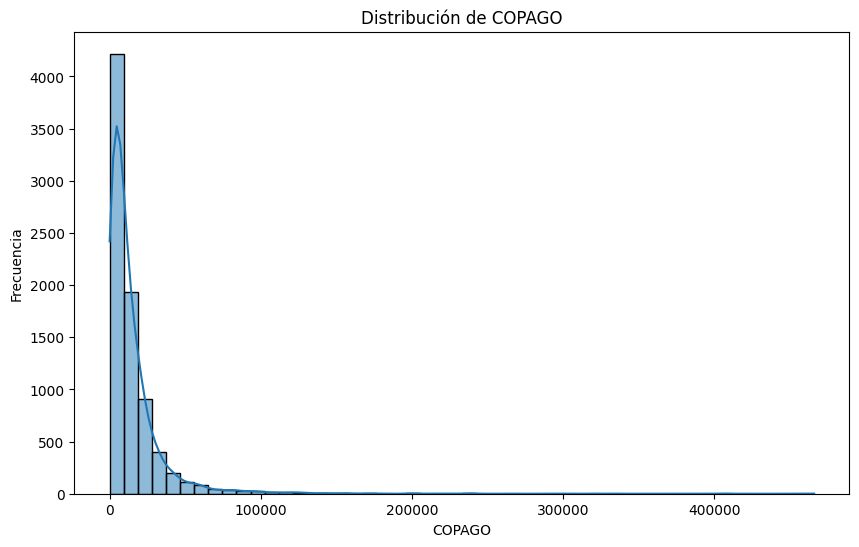

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(df['COPAGO'], bins=50, kde=True)
plt.title('Distribución de COPAGO')
plt.xlabel('COPAGO')
plt.ylabel('Frecuencia')
plt.show()

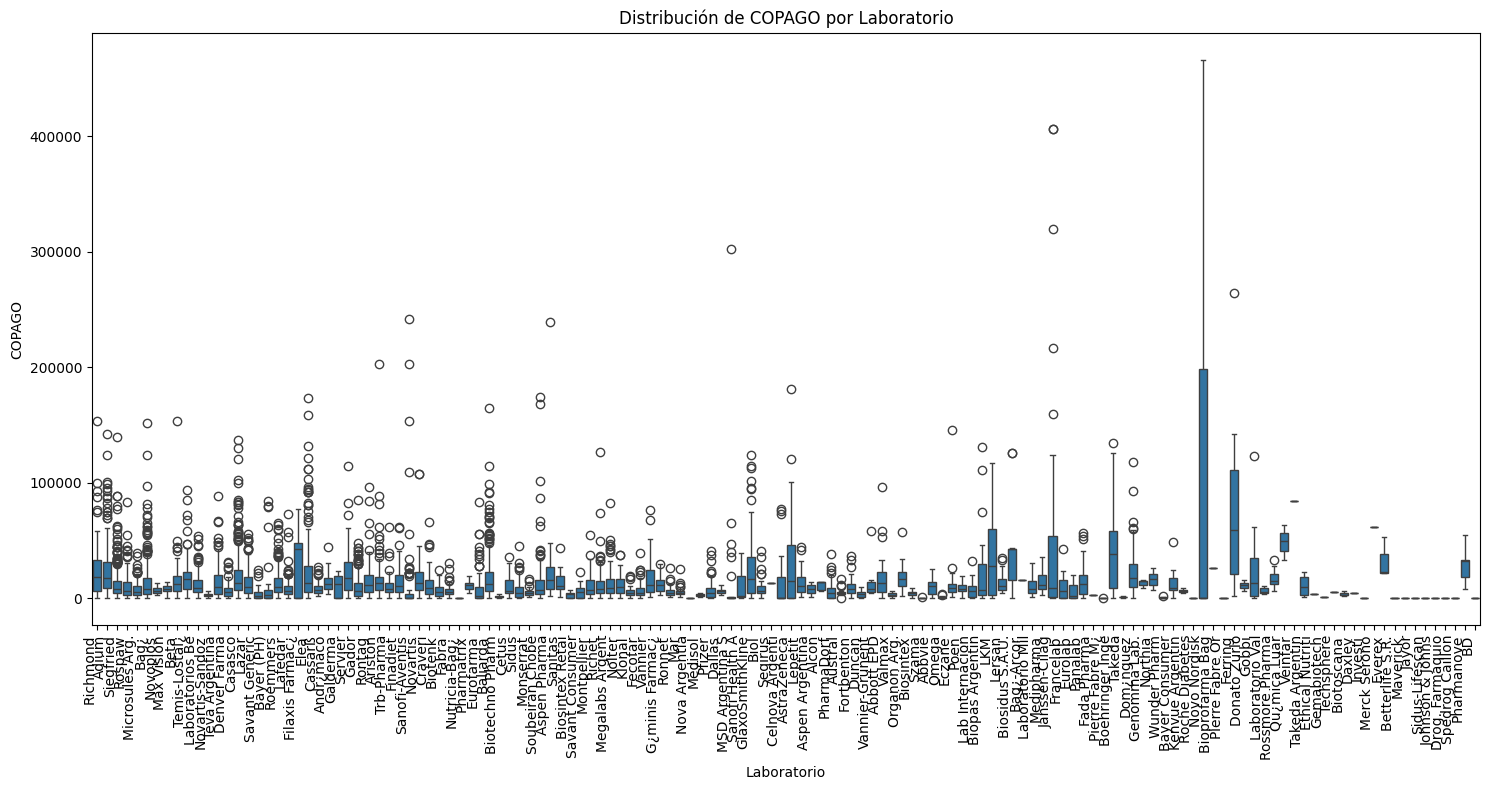

In [43]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='LABORATORIO', y='COPAGO', data=df)
plt.title('Distribución de COPAGO por Laboratorio')
plt.xlabel('Laboratorio')
plt.ylabel('COPAGO')
plt.xticks(rotation=90, ha='right') # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()

In [44]:
num_productos_copago_cero = df[df['COPAGO'] == 0].shape[0]
print(f"El número total de productos con COPAGO de 0 es: {num_productos_copago_cero}")

El número total de productos con COPAGO de 0 es: 377


#**Copago Promedio por Laboratorio**

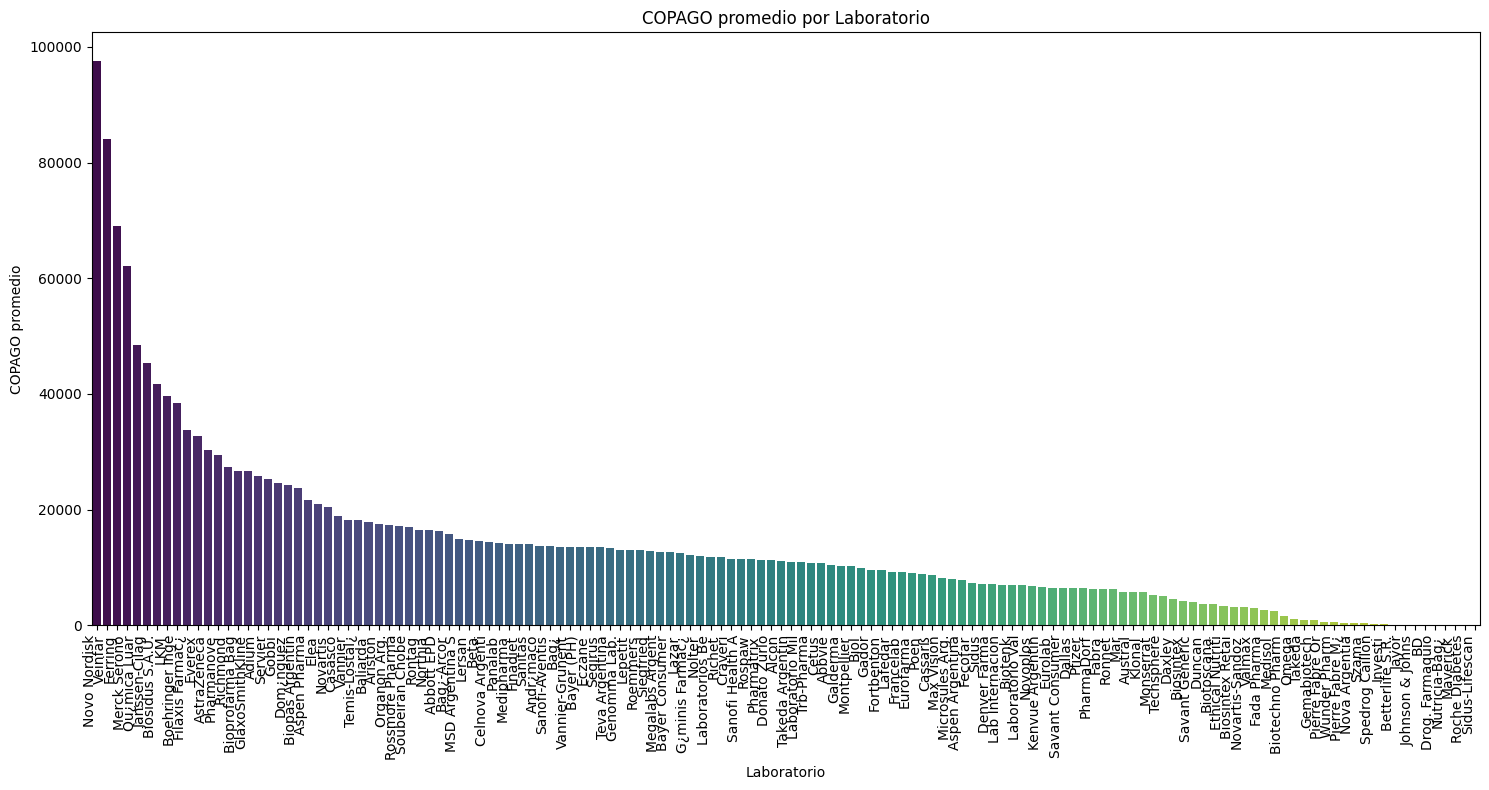

In [45]:
avg_copago_por_laboratorio = df.groupby('LABORATORIO')['COPAGO'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(x='LABORATORIO', y='COPAGO', data=avg_copago_por_laboratorio, palette='viridis', hue='LABORATORIO', legend=False)
plt.title('COPAGO promedio por Laboratorio')
plt.xlabel('Laboratorio')
plt.ylabel('COPAGO promedio')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

#**Distribución de Copago para los 10 Laboratorios con Mayor Copago Promedio**

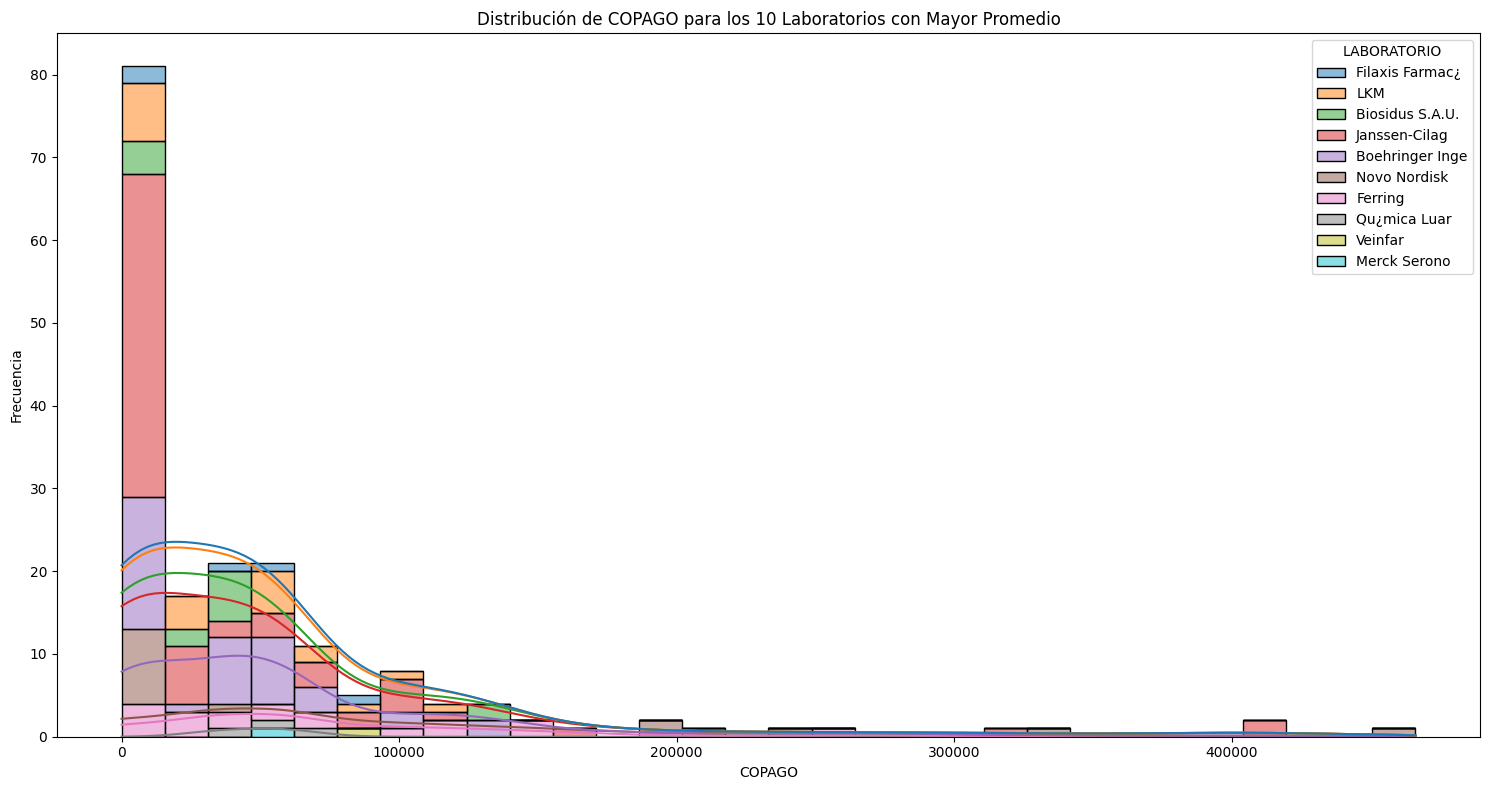

In [46]:
# Obtener los nombres de los 10 laboratorios con mayor COPAGO promedio
top_10_labs_names = avg_copago_por_laboratorio['LABORATORIO'].head(10).tolist()

# Filtrar el DataFrame original para incluir solo estos laboratorios
df_top_10_labs = df[df['LABORATORIO'].isin(top_10_labs_names)]

# Crear un histograma para la columna COPAGO de estos laboratorios
plt.figure(figsize=(15, 8))
sns.histplot(data=df_top_10_labs, x='COPAGO', hue='LABORATORIO', multiple='stack', bins=30, kde=True)
plt.title('Distribución de COPAGO para los 10 Laboratorios con Mayor Promedio')
plt.xlabel('COPAGO')
plt.ylabel('Frecuencia')
# plt.legend(title='Laboratorio') # Se elimina esta línea para evitar la advertencia
plt.tight_layout()
plt.show()

### **COPAGO Promedio de los 10 Laboratorios con Mayor Costo**

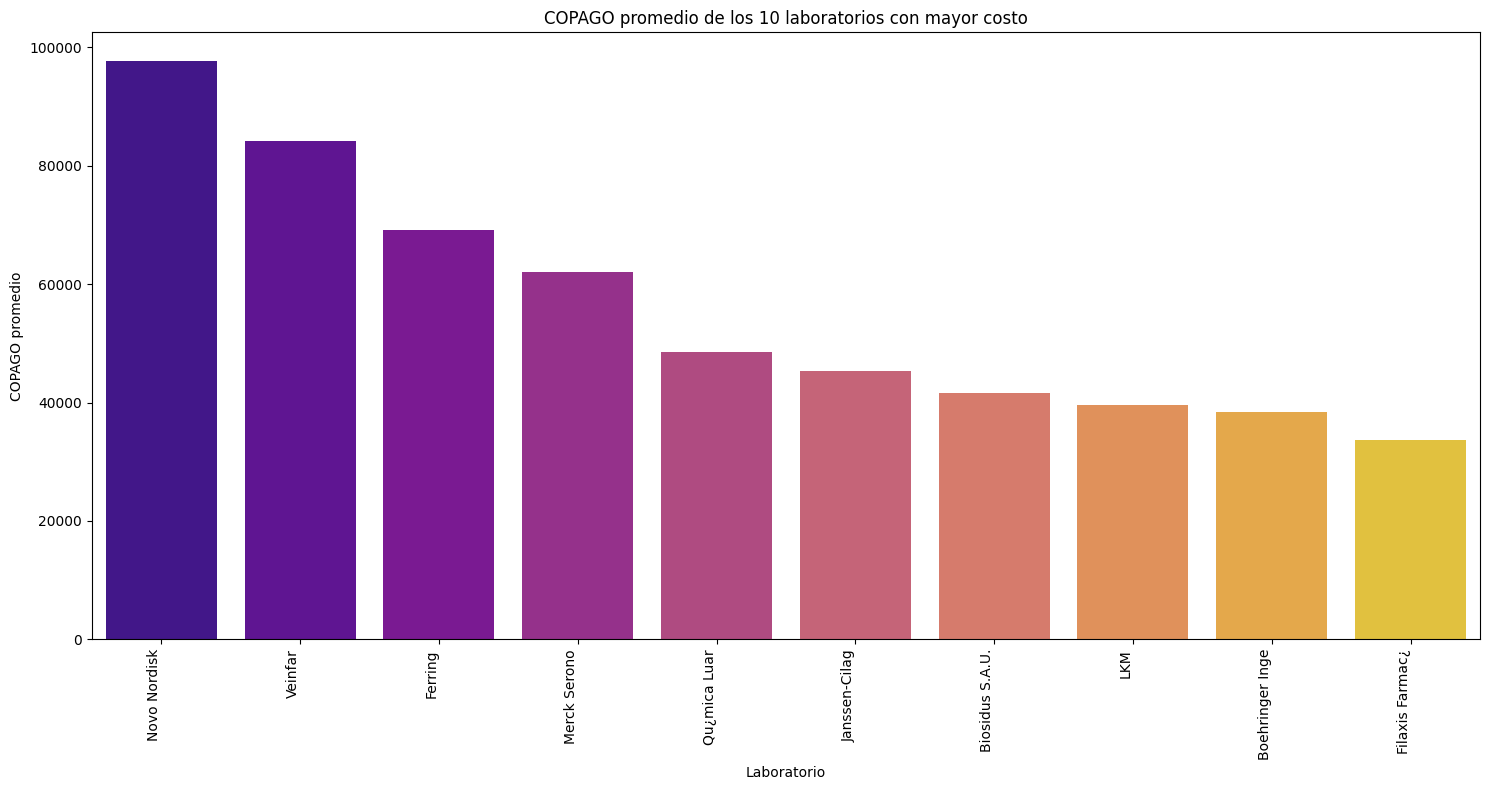

In [47]:
plt.figure(figsize=(15, 8))
sns.barplot(x='LABORATORIO', y='COPAGO', data=avg_copago_por_laboratorio.head(10), palette='plasma', hue='LABORATORIO', legend=False)
plt.title('COPAGO promedio de los 10 laboratorios con mayor costo')
plt.xlabel('Laboratorio')
plt.ylabel('COPAGO promedio')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

### **COPAGO Promedio de los 10 Laboratorios con Menor Costo**

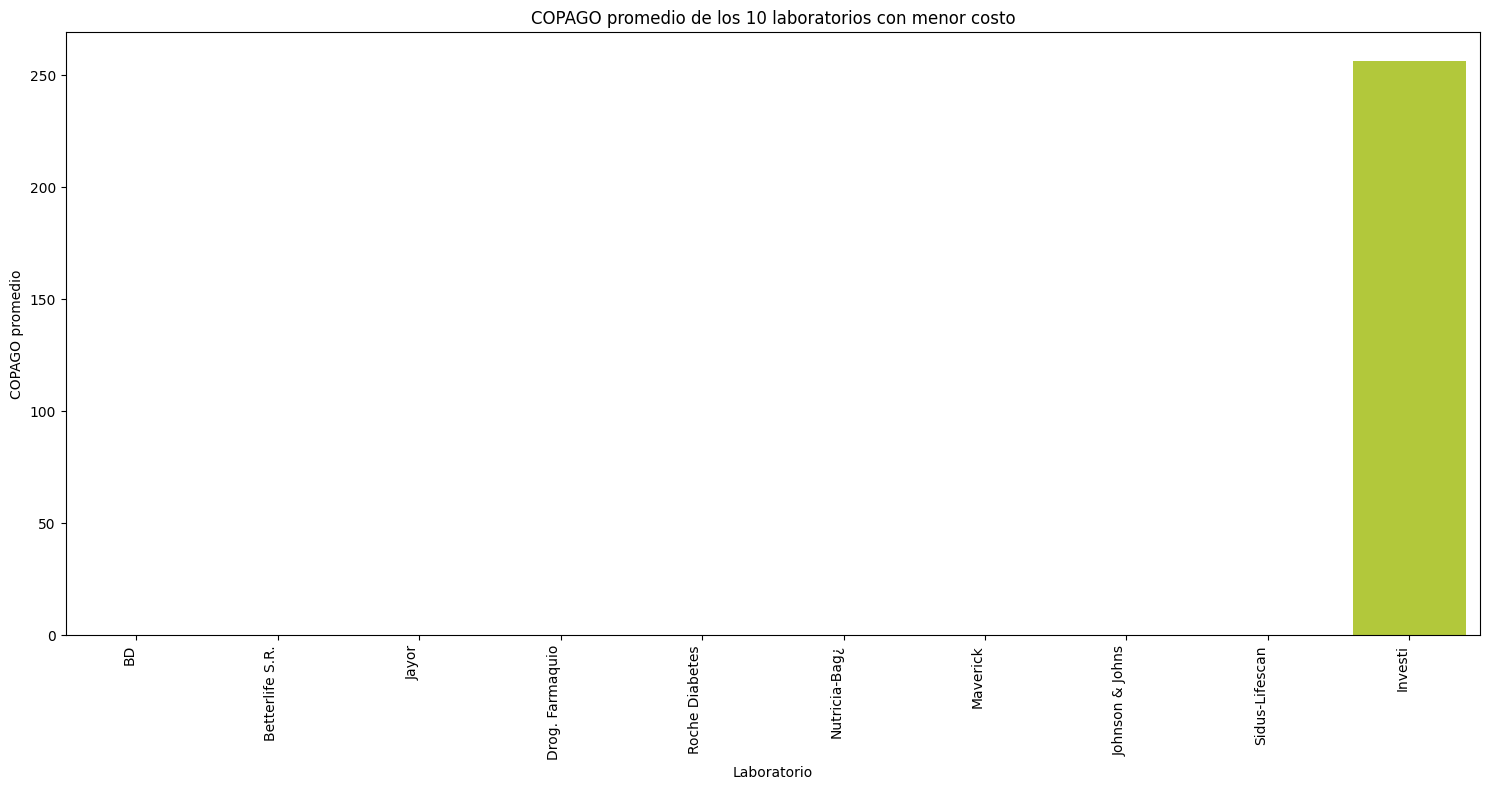

In [48]:
avg_copago_por_laboratorio_min = df.groupby('LABORATORIO')['COPAGO'].mean().sort_values(ascending=True).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(x='LABORATORIO', y='COPAGO', data=avg_copago_por_laboratorio_min.head(10), palette='viridis', hue='LABORATORIO', legend=False)
plt.title('COPAGO promedio de los 10 laboratorios con menor costo')
plt.xlabel('Laboratorio')
plt.ylabel('COPAGO promedio')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

### **Gráfico de dispersión: COPAGO vs. COBERTURA**

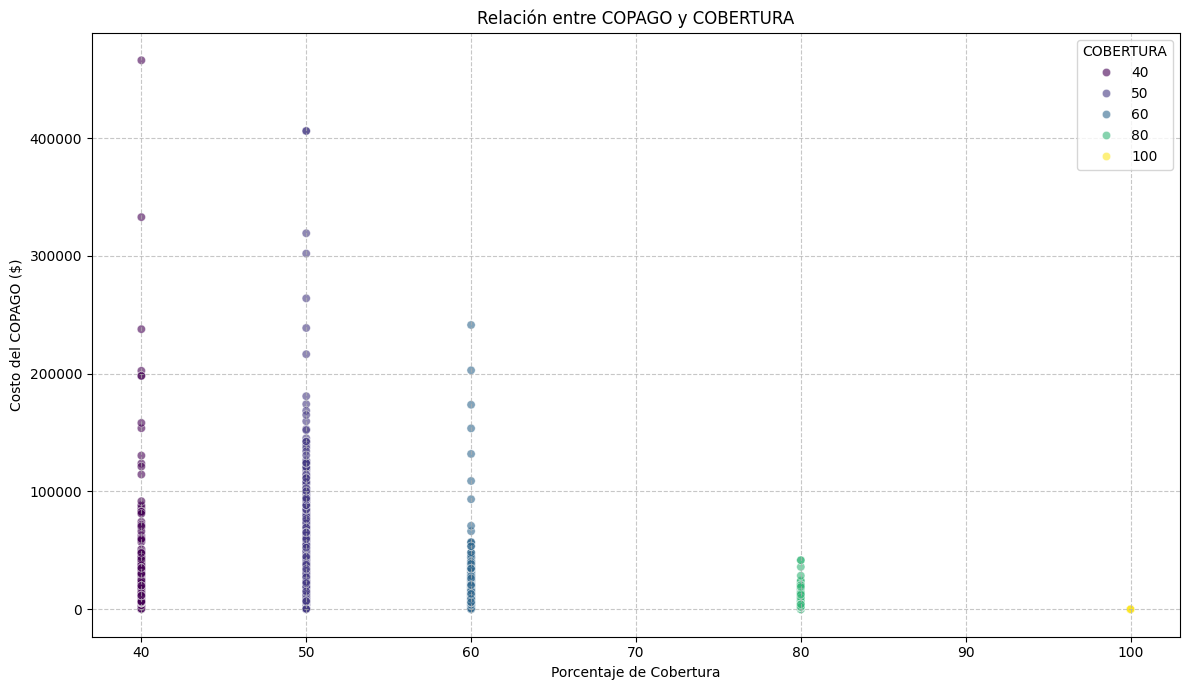

In [49]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='COBERTURA', y='COPAGO', data=df, alpha=0.6, hue='COBERTURA', palette='viridis', legend='full')
plt.title('Relación entre COPAGO y COBERTURA')
plt.xlabel('Porcentaje de Cobertura')
plt.ylabel('Costo del COPAGO ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Porcentaje de cobertura de los 10 medicamentos más caros**

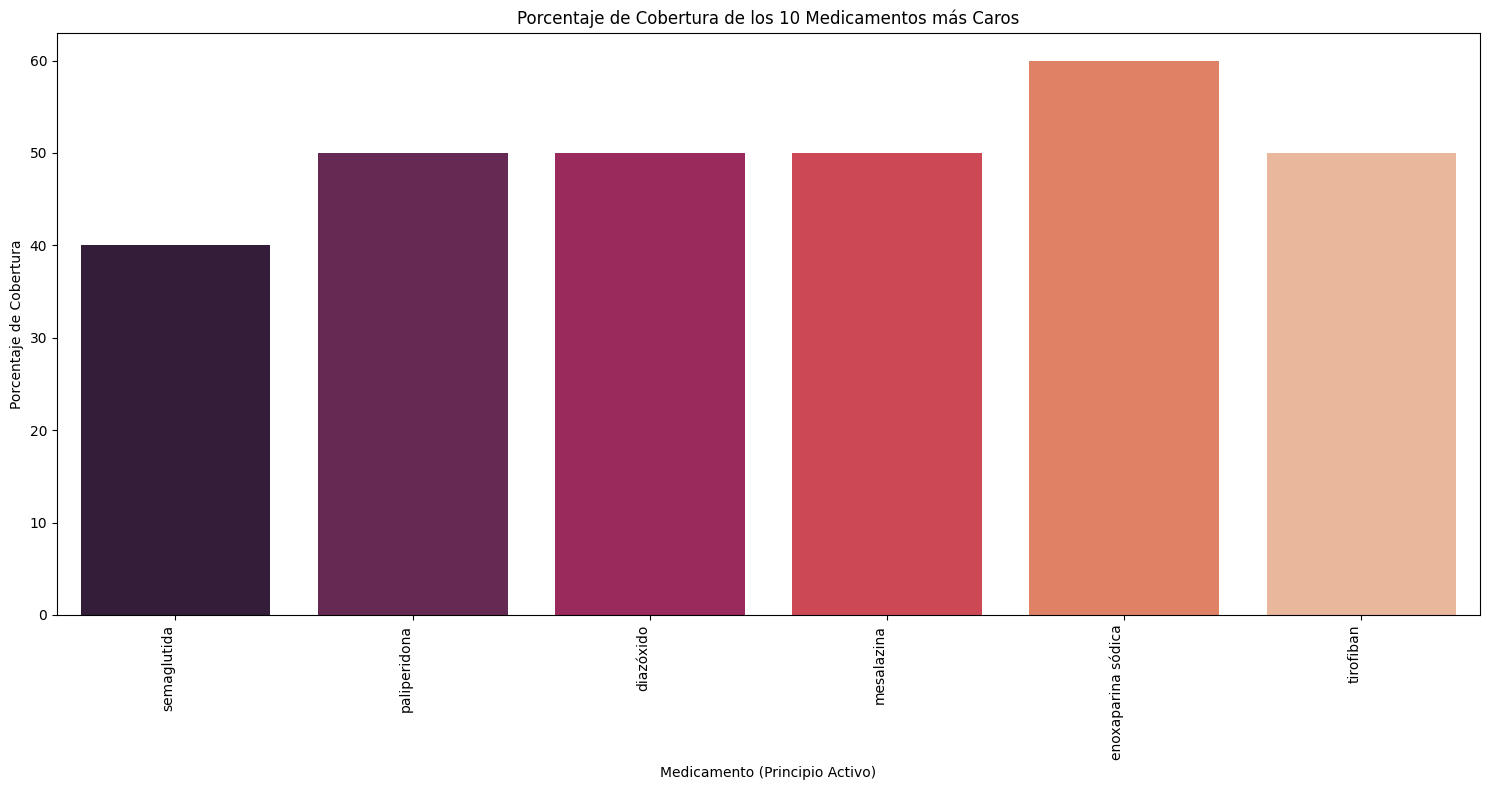

In [50]:
# Limpiar los nombres de las columnas para eliminar espacios en blanco o caracteres ocultos
df.columns = df.columns.str.strip()

# Obtener los 10 medicamentos con mayor COPAGO
top_10_copago = df.sort_values(by='COPAGO', ascending=False).head(10)

plt.figure(figsize=(15, 8))
sns.barplot(x='DROGA', y='COBERTURA', data=top_10_copago, palette='rocket', hue='DROGA', legend=False)
plt.title('Porcentaje de Cobertura de los 10 Medicamentos más Caros')
plt.xlabel('Medicamento (Principio Activo)')
plt.ylabel('Porcentaje de Cobertura')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()